In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import erf

import sys
sys.path.append('../')
import analysis_utils as utils
utils.load_plotting_setting()

import os

In [2]:
## General Parameters
kb = 8.617e-5      # eV K^-1
c  = 299792458     # m/s

## Halo DM parameters
rhoDM = 0.3e9    # dark matter mass density, eV/cm^3
vmin  = 5e-5     # minimum velocity to consider, natural units (c)
vesc  = 1.815e-3 # galactic escape velocity
v0    = 7.34e-4  # v0 parameter from Zurek group paper
ve    = 8.172e-4 # ve parameter from Zurek group paper

## Thermal DM parameters
t_thermal = 300                # K
vesc_earth = 3.729e-5  # Earth escape velocity

In [3]:
def f_thermal(v, mx, T, vesc_earth):
    """
    Truncated Maxwell-Boltzmann velocity distribution
    for DM thermalized at temperature T

    :param v: input velocity in natural units (array-like)
    :param mx: DM mass (eV)
    :param T: thermal temperature (K)
    :param vesc_earth: Earth's escape velocity in natural units
    """
    v0 = np.sqrt(2 * kb * T / mx)  # most probably velocity
    N0 = np.pi**1.5 * v0**3 * ( erf(vesc_earth/v0) - 2/np.sqrt(np.pi) * (vesc_earth/v0) * np.exp(-(vesc_earth/v0)**2))

    f = 4 * np.pi * v**2 * np.exp(-1 * v**2 / (v0**2))
    f[v > vesc_earth] = 0

    return f / N0

def f_halo(v):
    """
    DM velocity distribution in the Earth frame from Zurek group paper
    https://journals.aps.org/prd/pdf/10.1103/PhysRevD.100.035025
    note there is a typo in the sign of the exponential in the above paper
    
    :param v: input velocity (array-like)
    :return: velocity distribtuion (array-like)
    """
    N0 = np.pi**1.5 * v0**3 * ( erf(vesc/v0) - 2/np.sqrt(np.pi) * (vesc/v0) * np.exp(-(vesc/v0)**2))
    
    # v < (vesc - ve)
    f1 = np.exp( - (v+ve)**2 / v0**2 ) * (np.exp(4*v*ve / v0**2) - 1)
    # (vesc - ve) < v < (vesc + ve)
    f2 = np.exp( - (v-ve)**2 / v0**2 ) - np.exp(- vesc**2 / v0**2)

    f = np.zeros_like(v)
    g1 = v < (vesc - ve)
    g2 = np.logical_and( vesc-ve < v, v < vesc + ve)
    
    f[g1] = f1[g1]
    f[g2] = f2[g2]

    return f * np.pi * v * v0**2 / (N0 * ve)

Text(0, 0.5, 'Normalized probability')

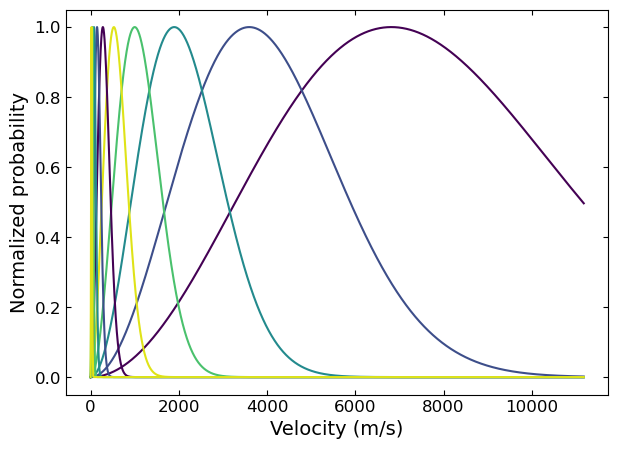

In [4]:
mx_list = np.logspace(-1, 4, 10) * 1e9
vv = np.linspace(0, vesc_earth, 20000)

for mx in mx_list:
    ff_thermal = f_thermal(vv, mx, t_thermal, vesc_earth)
    plt.plot(vv * c, ff_thermal / np.max(ff_thermal))

plt.xlabel('Velocity (m/s)')
plt.ylabel('Normalized probability')

## Quick projection using massless point charge solution

In [5]:
R_um = 0.083
nq = 20000
exposure = 30 * 24 * 3600  # s
thr = 2000                 # Set a 2 MeV threshold

mx_list = np.logspace(1, 8, 40)
alpha_list = np.logspace(-8, 0, 40)

qqs = np.empty(shape=(mx_list.size, alpha_list.size, nq))
drdqs = np.empty(shape=(mx_list.size, alpha_list.size, nq))
n_events = np.empty(shape=(mx_list.size, alpha_list.size))

for i, mx in enumerate(mx_list):
    for j, alphan in enumerate(alpha_list):

        file = rf'/Users/yuhan/work/nanospheres/data/dm_rate/thermal_dm/massless_mediator_pointcharge_halo_density/drdq_100mevthr_thermaldm_halodensity_nanosphere_{R_um:.2e}_{mx:.5e}_{alphan:.5e}_massless_pointcharge.npz'
        npz = np.load(file)

        qq = npz['q_kev']
        drdq = npz['drdq_hz_kev']

        qqs[i, j] = qq
        drdqs[i, j] = drdq
        n_events[i, j] = np.trapz(drdq[qq>thr], qq[qq>thr]) * exposure

Text(0, 0.5, '$dR/dq$ (Counts/keV/s)')

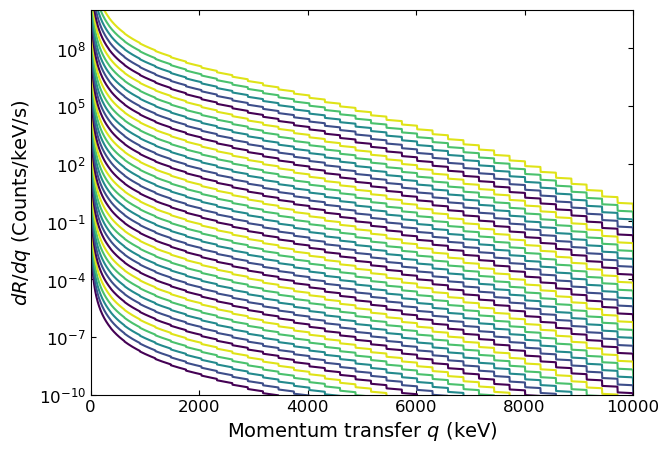

In [6]:
i = 20

# for i, mx in enumerate(mx_list):
for j, alphan in enumerate(alpha_list):
    plt.plot(qqs[i, j], drdqs[i, j])
    plt.yscale('log')

plt.xlim(0, 10000)
plt.ylim(1e-10, 1e10)
plt.xlabel('Momentum transfer $q$ (keV)')
plt.ylabel('$dR/dq$ (Counts/keV/s)')

In [7]:
alpha_lims = np.empty_like(mx_list)

for i, mx in enumerate(mx_list):
    int = np.interp(3, n_events[i], alpha_list)
    if int == 1e-1:
        int = np.nan
        
    alpha_lims[i] = int

Text(0, 0.5, '95% CL upper limits on $\\alpha_n$')

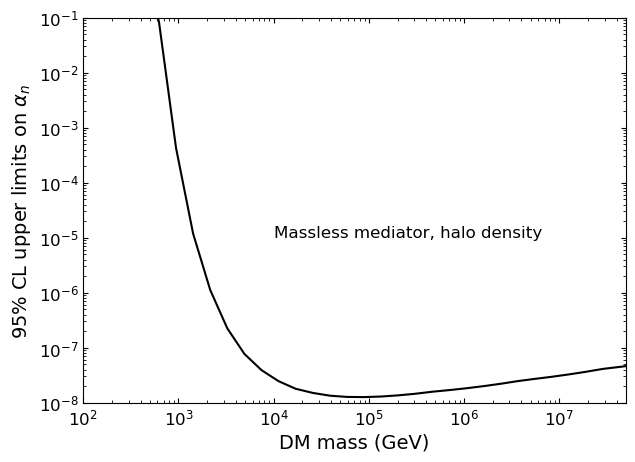

In [8]:
plt.plot(mx_list, alpha_lims, 'k-')

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e2, 5e7)
plt.ylim(1e-8, 1e-1)

plt.text(1e4, 1e-5, 'Massless mediator, halo density', fontsize=12)
plt.xlabel('DM mass (GeV)')
plt.ylabel(r'95% CL upper limits on $\alpha_n$')

## Now try with 10 um spheres, assuming a 150 MeV threshold

In [20]:
R_um = 5
nq = 20000
exposure = 30 * 24 * 3600  # s
thr = 150000                 # Set a 150 MeV threshold

mx_list = np.logspace(1, 8, 40)
alpha_list = np.logspace(-8, 0, 40)

qqs = np.empty(shape=(mx_list.size, alpha_list.size, nq))
drdqs = np.empty(shape=(mx_list.size, alpha_list.size, nq))
n_events = np.empty(shape=(mx_list.size, alpha_list.size))

for i, mx in enumerate(mx_list):
    for j, alphan in enumerate(alpha_list):

        file = rf'/Users/yuhan/work/nanospheres/data/dm_rate/thermal_dm/massless_mediator_pointcharge_halo_density/drdq_100mevthr_thermaldm_halodensity_microsphere_{R_um:.2e}_{mx:.5e}_{alphan:.5e}_massless_pointcharge.npz'
        npz = np.load(file)

        qq = npz['q_kev']
        drdq = npz['drdq_hz_kev']

        qqs[i, j] = qq
        drdqs[i, j] = drdq
        n_events[i, j] = np.trapz(drdq[qq>thr], qq[qq>thr]) * exposure

In [21]:
alpha_lims = np.empty_like(mx_list)

for i, mx in enumerate(mx_list):
    int = np.interp(3, n_events[i], alpha_list)
    if int == 1e-1:
        int = np.nan
        
    alpha_lims[i] = int

Text(0, 0.5, '$dR/dq$ (Counts/keV/s)')

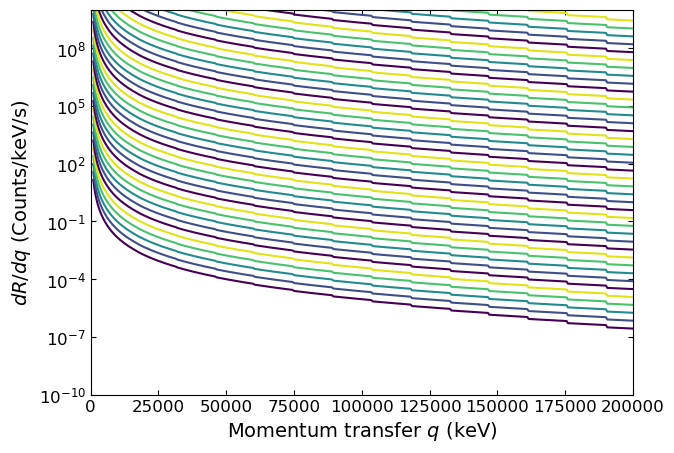

In [22]:
i = 39

# for i, mx in enumerate(mx_list):
for j, alphan in enumerate(alpha_list):
    plt.plot(qqs[i, j], drdqs[i, j])
    plt.yscale('log')

plt.xlim(0, 200000)
plt.ylim(1e-10, 1e10)
plt.xlabel('Momentum transfer $q$ (keV)')
plt.ylabel('$dR/dq$ (Counts/keV/s)')

Text(0, 0.5, '95% CL upper limits on $\\alpha_n$')

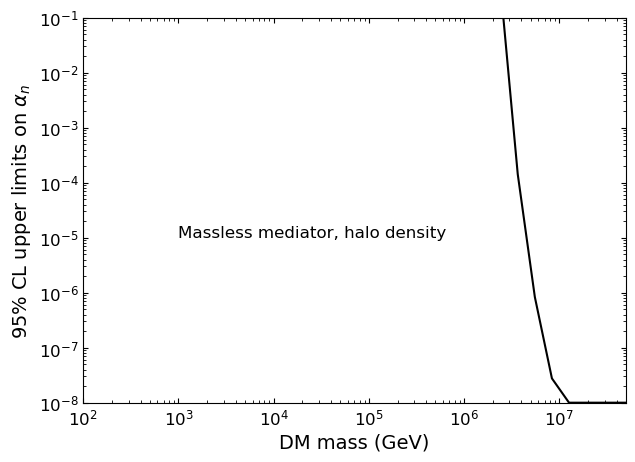

In [28]:
plt.plot(mx_list, alpha_lims, 'k-')

plt.xscale('log')
plt.yscale('log')

plt.xlim(1e2, 5e7)
plt.ylim(1e-8, 1e-1)

plt.text(1e3, 1e-5, 'Massless mediator, halo density', fontsize=12)
plt.xlabel('DM mass (GeV)')
plt.ylabel(r'95% CL upper limits on $\alpha_n$')

## Check the calculated spectrum

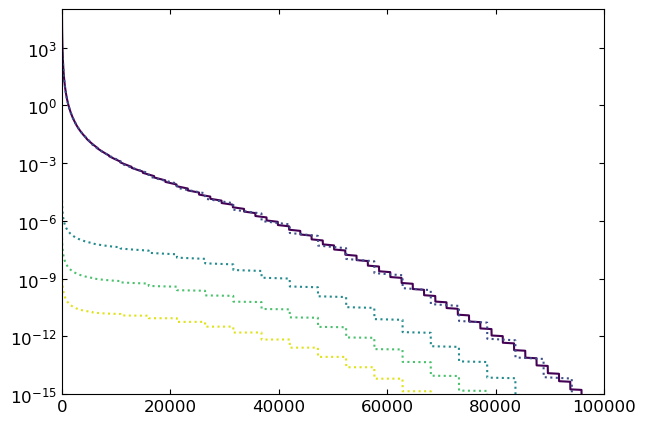

In [5]:
R_um = 0.083

mphi_list = [0, 0.1, 1, 10]
mx_list = np.logspace(1, 8, 80)
alpha_list = np.logspace(-12, -4, 80)

i_mx, j_alpha = 60, 50
mx, alpha = mx_list[i_mx], alpha_list[j_alpha]

outdir = f'/home/yt388/palmer_scratch/data/dm_rate/thermalized_dm/massless_mediator_pointcharge'
outfile = f'/drdq_100mevthr_thermaldm_nanosphere_{R_um:.2e}_{mx:.5e}_{alpha:.5e}_massless_pointcharge.npz'
npz = np.load(outdir+outfile)
qq = npz['q_kev']
drdq = npz['drdq_hz_kev']
plt.plot(qq, drdq)

for mphi in mphi_list:

    outdir = f'/home/yt388/palmer_scratch/data/dm_rate/thermalized_dm/mphi_{mphi:.0e}'
    outfile = f'/drdq_100mevthr_thermaldm_nanosphere_{R_um:.2e}_{mx:.5e}_{alpha:.5e}_{mphi:.0e}.npz'

    npz = np.load(outdir+outfile)
    qq = npz['q_kev']
    drdq = npz['drdq_hz_kev']

    plt.plot(qq, drdq, ':')

plt.xlim(0, 100000)
plt.ylim(1e-15, 1e5)
plt.yscale('log')

In [7]:
R_um = 0.083
# out_dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/dm_rate/thermalized_dm'
out_dir = r'/home/yt388/microspheres/dm_nanospheres/data_processed/dm_rate/thermalized_dm'

mphi_list = [0, 0.1, 1, 10]
qq = None
drdqzns = []

for mphi in mphi_list:
    outfile_name = f'drdqz_100mevthr_thermaldm_nanosphere_{R_um:.2e}_thermalized_dm_ampdepsigma_{mphi:.0e}.npz'
    outfile = os.path.join(out_dir, outfile_name)

    npz = np.load(outfile)
    qq = npz['bc_kev']
    drdqzn = npz['drdqzn']
    drdqzns.append(drdqzn)

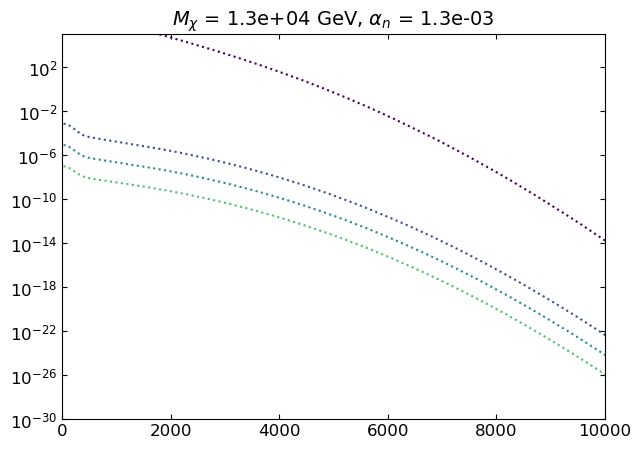

In [14]:
mx_list = np.logspace(1, 8, 80)
alpha_list_extended = np.logspace(-12, 4, 159)
alpha_list = alpha_list_extended[alpha_list_extended<1e-2]

i_mx, j_alpha = 35, 90
mx, alpha = mx_list[i_mx], alpha_list[j_alpha]

for i, mphi in enumerate(mphi_list):
    plt.plot(qq, drdqzns[i][i_mx, j_alpha], ':')

    # outdir = f'/home/yt388/palmer_scratch/data/dm_rate/thermalized_dm/mphi_{mphi:.0e}'
    # outfile = f'/drdq_100mevthr_thermaldm_nanosphere_{R_um:.2e}_{mx:.5e}_{alpha:.5e}_{mphi:.0e}.npz'
    # npz = np.load(outdir+outfile)
    # _qq = npz['q_kev']
    # _drdq = npz['drdq_hz_kev']

    # plt.plot(_qq, _drdq, '-')
plt.title(fr'$M_\chi$ = {mx:.1e} GeV, $\alpha_n$ = {alpha:.1e}')

plt.xlim(0, 10000)
plt.ylim(1e-30, 1e5)
plt.yscale('log')